#FLIGHT PRICE EDA

**WE HAVE A REAL WORLD DATA OF FLIGHT PRICE AND TODAY WE ARE GOING TO DO THE EDA ON IT FIRST WE CHECK THE DATA AND UNDERSTND EACH COLUMNS AND THE VALUES TYPE AND FIND OUT THE MISSING VALUES AND IF WE FOUND AND NULL VALUES WE GONNA FILL OR DROP THEM ACCORDING TO DATA,THEN WE FILL CLEAR THE DATA REMORE THE ERROR DATA FIX THE DATA WITH THE HELP OF LIBABRARIES AND FUNCTION LIKE ( ONE HOTHAND ENCODING,SCALING,LEBEL ENCODING) AND MAKE THE DATA READY TO PERFOM THE EDA AND OBSERVE THE DATA WITH THE HELP OF VISUALIZATION AND PROVIDE THE BEST INSIGHT FROM THEM AND THEN WE SPLIT THE DATA INTO CAT AND NUMS AND DO TRAIN AND TEST ON IT AND FIND OUT THE TARGET VARIABLE**

In [ ]:
# IMPORTING THE LIBRARIES WHICH ARE REQUIRED FOR EDA.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_excel('flight_price.xlsx')  # loading the data_set with the help of pandas libarary function.And store in the df variable.
df


,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302
...,...,...,...,...,...,...,...,...,...,...,...
10678,Air Asia,9/04/2019,Kolkata,Banglore,CCU → BLR,19:55,22:25,2h 30m,non-stop,No info,4107
10679,Air India,27/04/2019,Kolkata,Banglore,CCU → BLR,20:45,23:20,2h 35m,non-stop,No info,4145
10680,Jet Airways,27/04/2019,Banglore,Delhi,BLR → DEL,08:20,11:20,3h,non-stop,No info,7229
10681,Vistara,01/03/2019,Banglore,New Delhi,BLR → DEL,11:30,14:10,2h 40m,non-stop,No info,12648


In [ ]:
df.head()  # with the help of "head()" function we check the first 5 rows of the data

,Airline,Date_of_Journey,Source,Destination,Route,Dep_Time,Arrival_Time,Duration,Total_Stops,Additional_Info,Price
0,IndiGo,24/03/2019,Banglore,New Delhi,BLR → DEL,22:20,01:10 22 Mar,2h 50m,non-stop,No info,3897
1,Air India,1/05/2019,Kolkata,Banglore,CCU → IXR → BBI → BLR,05:50,13:15,7h 25m,2 stops,No info,7662
2,Jet Airways,9/06/2019,Delhi,Cochin,DEL → LKO → BOM → COK,09:25,04:25 10 Jun,19h,2 stops,No info,13882
3,IndiGo,12/05/2019,Kolkata,Banglore,CCU → NAG → BLR,18:05,23:30,5h 25m,1 stop,No info,6218
4,IndiGo,01/03/2019,Banglore,New Delhi,BLR → NAG → DEL,16:50,21:35,4h 45m,1 stop,No info,13302


In [ ]:
df.info()   # with the help of ".info" function we are checking the data types and all the other information about are data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10683 entries, 0 to 10682
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10683 non-null  object
 1   Date_of_Journey  10683 non-null  object
 2   Source           10683 non-null  object
 3   Destination      10683 non-null  object
 4   Route            10682 non-null  object
 5   Dep_Time         10683 non-null  object
 6   Arrival_Time     10683 non-null  object
 7   Duration         10683 non-null  object
 8   Total_Stops      10682 non-null  object
 9   Additional_Info  10683 non-null  object
 10  Price            10683 non-null  int64 
dtypes: int64(1), object(10)
memory usage: 918.2+ KB


In [ ]:
df.isnull().sum()  # checking the null values in the data set

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,1
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,1
Additional_Info,0


**there is only 1 null values in the Route and Total_Stops columns and as we no that without Route and stop no flight can travel so this is an error in the data maybe so we are gonna drop the null value from columns**

In [ ]:
df.dropna(inplace=True) #now we have drop the null values becuase that was maybe an error

In [ ]:
df.isnull().sum()  # again checking the null values and as we can see now there is no null values in the data

,0
Airline,0
Date_of_Journey,0
Source,0
Destination,0
Route,0
Dep_Time,0
Arrival_Time,0
Duration,0
Total_Stops,0
Additional_Info,0


In [ ]:
df.shape   # checking the rows and columns count

(10682, 11)

In [ ]:
df.columns   # checking the each columms name for better data undersatndig

Index(['Airline', 'Date_of_Journey', 'Source', 'Destination', 'Route',
       'Dep_Time', 'Arrival_Time', 'Duration', 'Total_Stops',
       'Additional_Info', 'Price'],
      dtype='object')

In [ ]:
df.dtypes   # checking the data type of each columns

,0
Airline,object
Date_of_Journey,object
Source,object
Destination,object
Route,object
Dep_Time,object
Arrival_Time,object
Duration,object
Total_Stops,object
Additional_Info,object


**now we have seen the data very carefull and as we have understoond the data we are not gonna remove outlier because it's a real world travel data and each air lines details are importantso we are not gonna remove the outliers**

#Feature Engineering

In [ ]:
df['date'] = df.Date_of_Journey.str.split('/').str[0]   # as we have date of journey so we are separting day,monnth and year.
df['month'] = df.Date_of_Journey.str.split('/').str[1]
df['year'] = df.Date_of_Journey.str.split('/').str[2]

In [ ]:
df["date"] = df['date'].astype(int)  # as we have separate the day,month and year now we are converting them into object to int
df["month"] = df['month'].astype(int)
df["year"] = df['year'].astype(int)

In [ ]:
df.drop(columns='Date_of_Journey',inplace=True) # now we have day,month and year columns do we don't need date of journey column so we are just droping the column

In [ ]:
df["dep_hour"] = df.Dep_Time.str.split(":").str[0]  # the same thing we are doing for dep_time which we have done in date of journey column
df["dep_mint"] = df.Dep_Time.str.split(":").str[1]
df['dep_hour'] = df["dep_hour"].astype(int)  # converting into int
df['dep_mint'] = df["dep_mint"].astype(int)

In [ ]:
df.drop(columns='Dep_Time',inplace=True) # as you know now we have hour and minute column so we are droping the dep_time column

In [ ]:
df['Arrival_hour'] = df["Arrival_Time"].str.split(" ").str[0].str.split(":").str[0]
df['Arrival_mint'] = df["Arrival_Time"].str.split(" ").str[0].str.split(":").str[1]


In [ ]:
df['Arrival_hour'] = df["Arrival_hour"].astype(int)
df['Arrival_mint'] = df["Arrival_mint"].astype(int)


In [ ]:
df.drop(columns='Arrival_Time',inplace=True)

In [ ]:
df['duration_hour'] = df.Duration.str.split(" ").str[0].str.split("h").str[0].str.split("m").str[0]
df['duration_mint'] = df.Duration.str.split("h").str[1].str.split("m").str[0]

In [ ]:
df["duration_hour"] = df['duration_hour'].astype(int)
df['duration_mint'] = df['duration_mint'].fillna('0').str.strip().str.replace('m', '').replace('', '0').astype(int)

In [ ]:
df.drop(columns='Duration',inplace=True)

In [ ]:
df.Total_Stops.unique()  # checking the unique value in total stop columns and as we observe the data we will now use split fumction here because there is only 4 unique value

array(['non-stop', '2 stops', '1 stop', '3 stops', '4 stops'],
      dtype=object)

In [ ]:
df["Total_Stops"] = df["Total_Stops"].map({"non-stop":0,"1 stop":1,"2 stops":2,"3 stops":3,"4 stops":4}) # we are using map/label encoding function

In [ ]:
df["Total_Stops"].unique()

array([0, 2, 1, 3, 4])

In [ ]:
df.info() #checking the data type and value count for each column

<class 'pandas.core.frame.DataFrame'>
Index: 10682 entries, 0 to 10682
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Airline          10682 non-null  object
 1   Source           10682 non-null  object
 2   Destination      10682 non-null  object
 3   Route            10682 non-null  object
 4   Total_Stops      10682 non-null  int64 
 5   Additional_Info  10682 non-null  object
 6   Price            10682 non-null  int64 
 7   date             10682 non-null  int64 
 8   month            10682 non-null  int64 
 9   year             10682 non-null  int64 
 10  dep_hour         10682 non-null  int64 
 11  dep_mint         10682 non-null  int64 
 12  Arrival_hour     10682 non-null  int64 
 13  Arrival_mint     10682 non-null  int64 
 14  duration_hour    10682 non-null  int64 
 15  duration_mint    10682 non-null  int64 
dtypes: int64(11), object(5)
memory usage: 1.4+ MB


In [ ]:
df.Route.unique()  # checking the unique values

array(['BLR → DEL', 'CCU → IXR → BBI → BLR', 'DEL → LKO → BOM → COK',
       'CCU → NAG → BLR', 'BLR → NAG → DEL', 'CCU → BLR',
       'BLR → BOM → DEL', 'DEL → BOM → COK', 'DEL → BLR → COK',
       'MAA → CCU', 'CCU → BOM → BLR', 'DEL → AMD → BOM → COK',
       'DEL → PNQ → COK', 'DEL → CCU → BOM → COK', 'BLR → COK → DEL',
       'DEL → IDR → BOM → COK', 'DEL → LKO → COK',
       'CCU → GAU → DEL → BLR', 'DEL → NAG → BOM → COK',
       'CCU → MAA → BLR', 'DEL → HYD → COK', 'CCU → HYD → BLR',
       'DEL → COK', 'CCU → DEL → BLR', 'BLR → BOM → AMD → DEL',
       'BOM → DEL → HYD', 'DEL → MAA → COK', 'BOM → HYD',
       'DEL → BHO → BOM → COK', 'DEL → JAI → BOM → COK',
       'DEL → ATQ → BOM → COK', 'DEL → JDH → BOM → COK',
       'CCU → BBI → BOM → BLR', 'BLR → MAA → DEL',
       'DEL → GOI → BOM → COK', 'DEL → BDQ → BOM → COK',
       'CCU → JAI → BOM → BLR', 'CCU → BBI → BLR', 'BLR → HYD → DEL',
       'DEL → TRV → COK', 'CCU → IXR → DEL → BLR',
       'DEL → IXU → BOM → COK', 'CCU 

In [ ]:
df.Additional_Info.unique() # checking the unique values

array(['No info', 'In-flight meal not included',
       'No check-in baggage included', '1 Short layover', 'No Info',
       '1 Long layover', 'Change airports', 'Business class',
       'Red-eye flight', '2 Long layover'], dtype=object)

**we have checked Route and Additional columns unique values and we obsever that these two columns are not that much important for the data we can drop them becuase we already have total_stop columns both are proving the same details so we don't need Route column for now so we drop it and for additional column there is now impotant details are available so we decided to drop the both columns**

In [ ]:
df.drop(columns=['Route','Additional_Info'],inplace=True)

In [ ]:
df.head()  # checking our final data frame.

,Airline,Source,Destination,Total_Stops,Price,date,month,year,dep_hour,dep_mint,Arrival_hour,Arrival_mint,duration_hour,duration_mint
0,IndiGo,Banglore,New Delhi,0,3897,24,3,2019,22,20,1,10,2,50
1,Air India,Kolkata,Banglore,2,7662,1,5,2019,5,50,13,15,7,25
2,Jet Airways,Delhi,Cochin,2,13882,9,6,2019,9,25,4,25,19,0
3,IndiGo,Kolkata,Banglore,1,6218,12,5,2019,18,5,23,30,5,25
4,IndiGo,Banglore,New Delhi,1,13302,1,3,2019,16,50,21,35,4,45


In [ ]:
cat = []   # we are seprating data into categorical
nums = []  # and numberic data so we can do univariate analysis in one shot for each columns with th help of loop

for col in df.columns:
  if df[col].dtype != "object":
    nums.append(col)
  else:
    cat.append(col)

print(cat)
print(nums)

['Airline', 'Source', 'Destination']
['Total_Stops', 'Price', 'date', 'month', 'year', 'dep_hour', 'dep_mint', 'Arrival_hour', 'Arrival_mint', 'duration_hour', 'duration_mint']


**so far so good, now we have succefully done all the imporant data cleaning are data is ready for the visualzation now we do visualzation and find out the best insight from them**

# Univariate Analysis

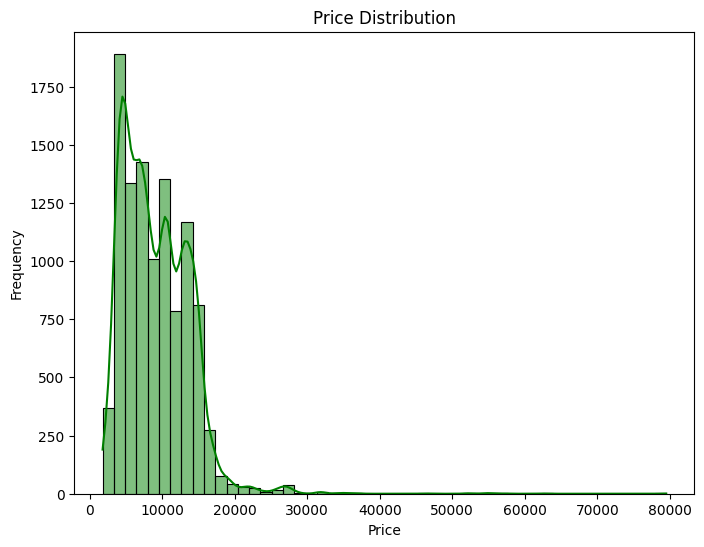

In [ ]:
plt.figure(figsize=(8,6))
sns.histplot(df['Price'],bins = 50, kde =True , color = "green")
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.show()

**price distribution is a right skewed and most of the tickt are around 2500 to 15000.**

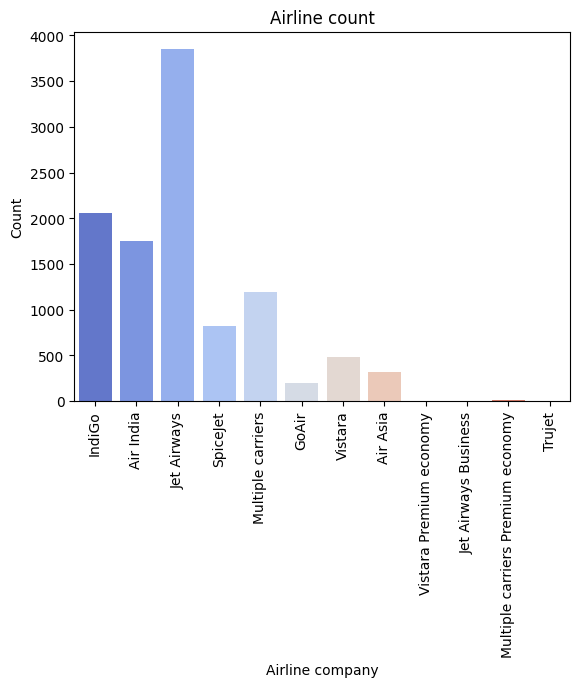

In [ ]:
sns.countplot(x = 'Airline', data = df , palette="coolwarm")
plt.title("Airline count")
plt.xlabel("Airline company")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

**Jet Airways are the leading company, Jet Airways has the highest flight in 2019 and indigo has second highest**

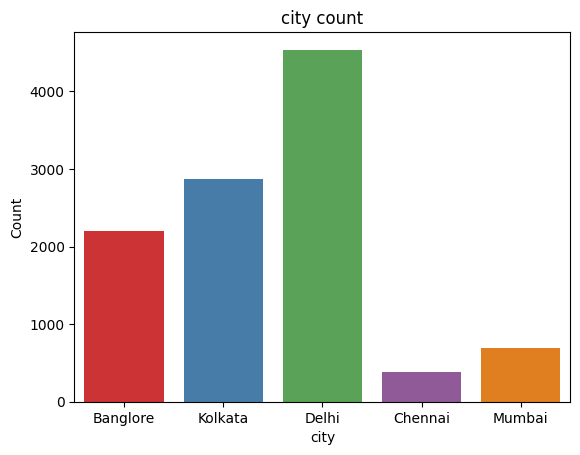

In [ ]:
sns.countplot(x = 'Source', data = df , palette="Set1")
plt.title("city count")
plt.xlabel("city")
plt.ylabel("Count")
plt.show()

**most flight are takeoff from delhi airpot, 4000+ flight has takeoff from delhi in 2019**

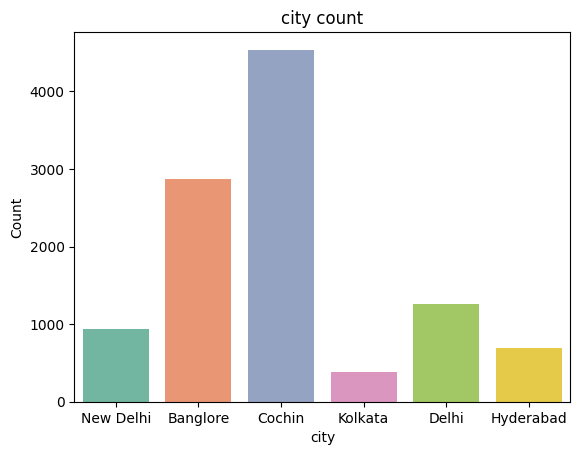

In [ ]:
sns.countplot(x = 'Destination', data = df , palette="Set2")
plt.title("city count")
plt.xlabel("city")
plt.ylabel("Count")
plt.show()

**Cochin Highest number of flights, This suggests Cochin is the most popular and Bangalore is Second highest place**



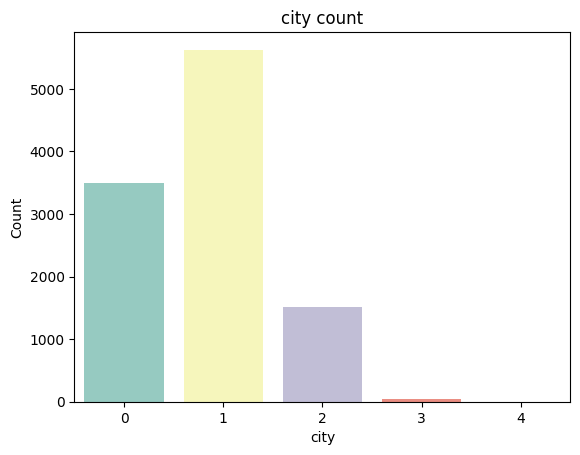

In [ ]:
sns.countplot(x = 'Total_Stops', data = df , palette="Set3")
plt.title("city count")
plt.xlabel("city")
plt.ylabel("Count")
plt.show()

**majority of flights has only one stop,but we can see that there are some flight are with 0 stop it's not possible to have zero stop so maybe that flight maybe got cancelled or there are some error in the data we are not about it that's why did not drop those values.**

#Bivariate Analysis

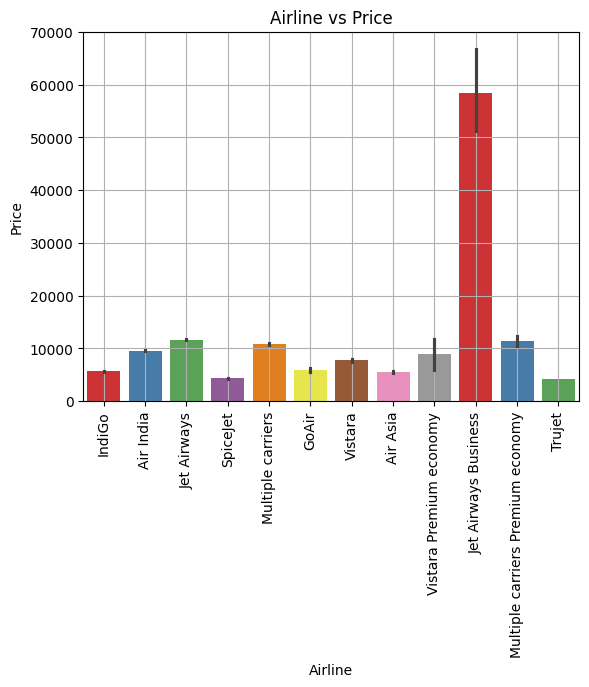

In [ ]:
sns.barplot(x = "Airline" , y = "Price" , data = df,palette= "Set1")
plt.title("Airline vs Price")
plt.xlabel("Airline")
plt.ylabel("Price")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

**jet airways bussiness has most expansive flights as compare to others all flight price are under 15k except jet airways business. jet airways business flight price are more than 50k.**

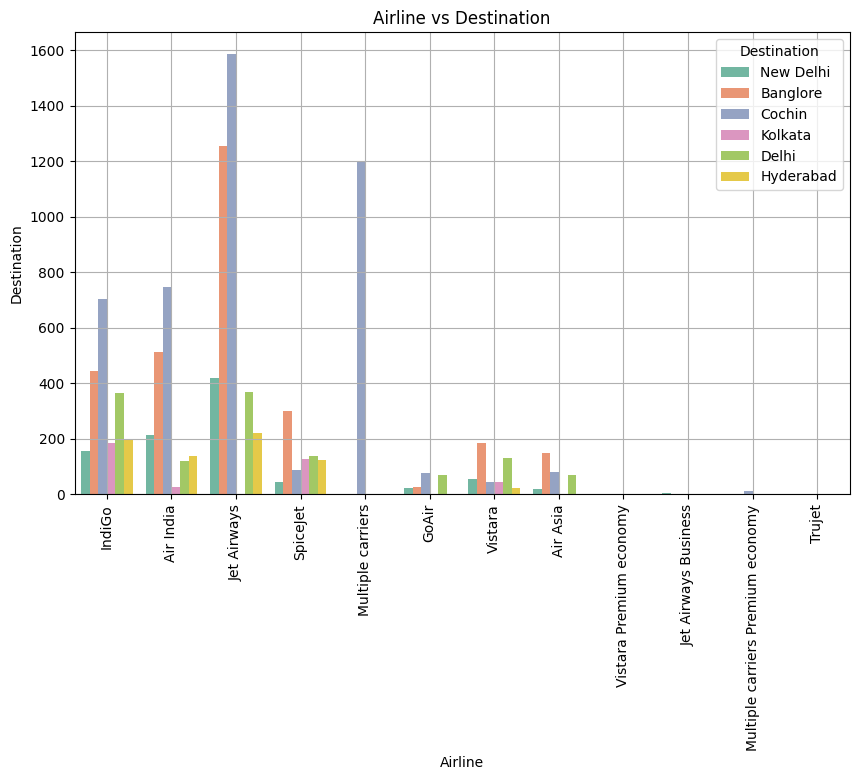

In [ ]:
plt.figure(figsize=(10,6))
sns.countplot(x = "Airline" , hue = "Destination" , data = df,palette= "Set2")
plt.title("Airline vs Destination")
plt.xlabel("Airline")
plt.ylabel("Destination")
plt.xticks(rotation=90)
plt.grid(True)
plt.show()

**almost all airline flight destination are cochin.cochin is the most popular destination city allover in india.**

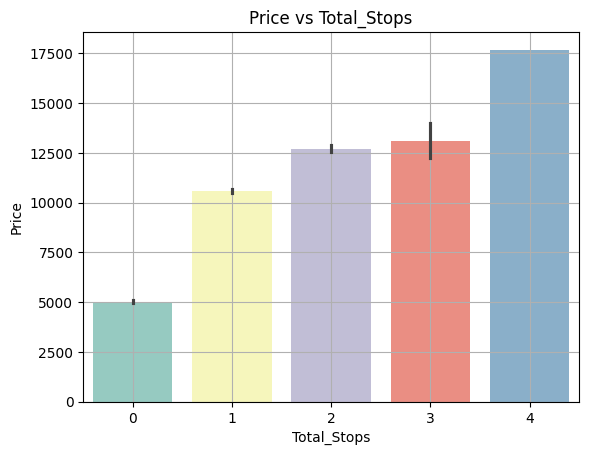

In [ ]:
sns.barplot(x = "Total_Stops" , y = "Price" , data = df,palette= "Set3")
plt.title("Price vs Total_Stops")
plt.xlabel("Total_Stops")
plt.ylabel("Price")
plt.grid(True)
plt.show()

**4 stops has the highest ticket price**

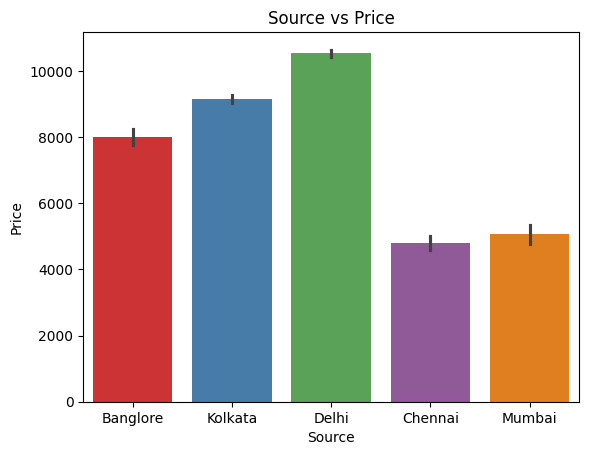

In [ ]:
sns.barplot(x = "Source" , y = "Price" , data = df,palette= "Set1")
plt.title("Source vs Price")
plt.xlabel("Source")
plt.ylabel("Price")
plt.show()

**delhi has the highest ticket price**

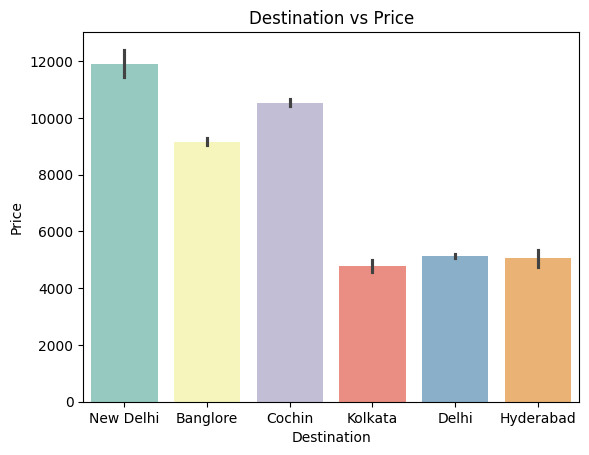

In [ ]:
sns.barplot(x = "Destination" , y = "Price" , data = df,palette= "Set3")
plt.title("Destination vs Price")
plt.xlabel("Destination")
plt.ylabel("Price")
plt.show()

**new delhi is the most expansive destination among all destination**

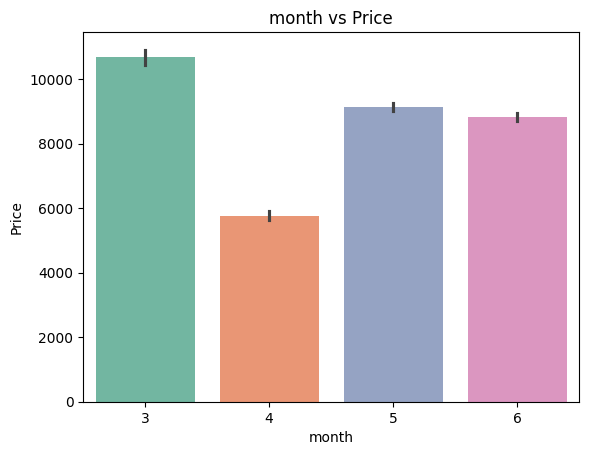

In [ ]:
sns.barplot(x = "month" , y = "Price" , data = df,palette= "Set2")
plt.title("month vs Price")
plt.xlabel("month")
plt.ylabel("Price")
plt.show()

**most highest ticket has sold out in the month of march**

#Multivariate Analysis

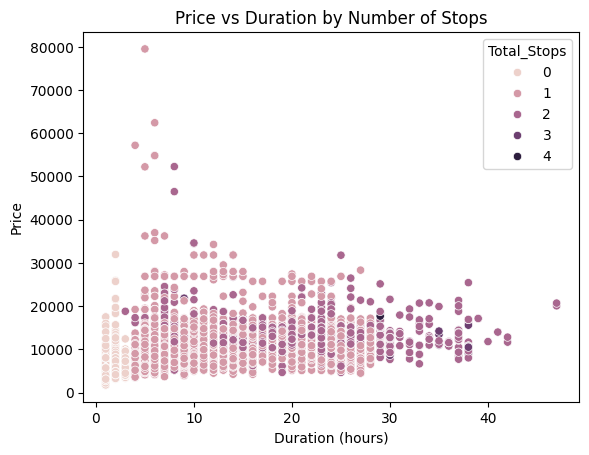

In [ ]:
sns.scatterplot(x='duration_hour',y='Price',hue='Total_Stops',data=df)
plt.title('Price vs Duration by Number of Stops')
plt.xlabel('Duration (hours)')
plt.ylabel('Price')
plt.show()


**Longer duration + more stops → generally lower prices**

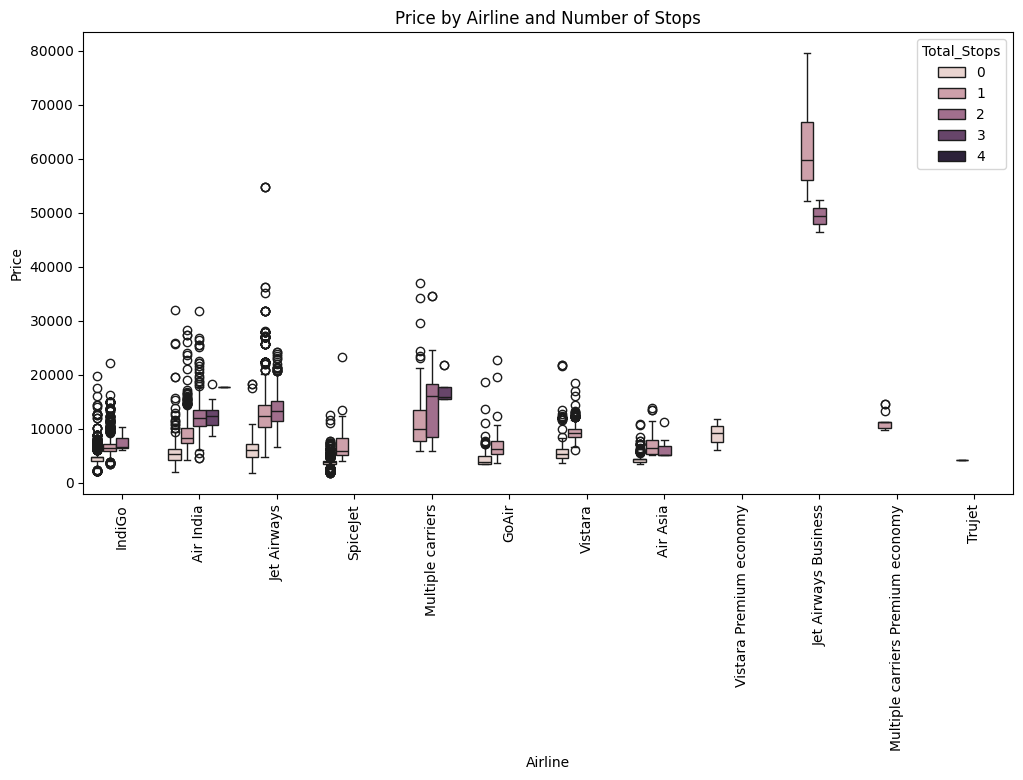

In [ ]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Airline',y='Price',hue='Total_Stops',data=df)
plt.xticks(rotation=90)
plt.title('Price by Airline and Number of Stops')
plt.show()


**Some airlines remain expensive even with stops Others drop price aggressively with more stops**

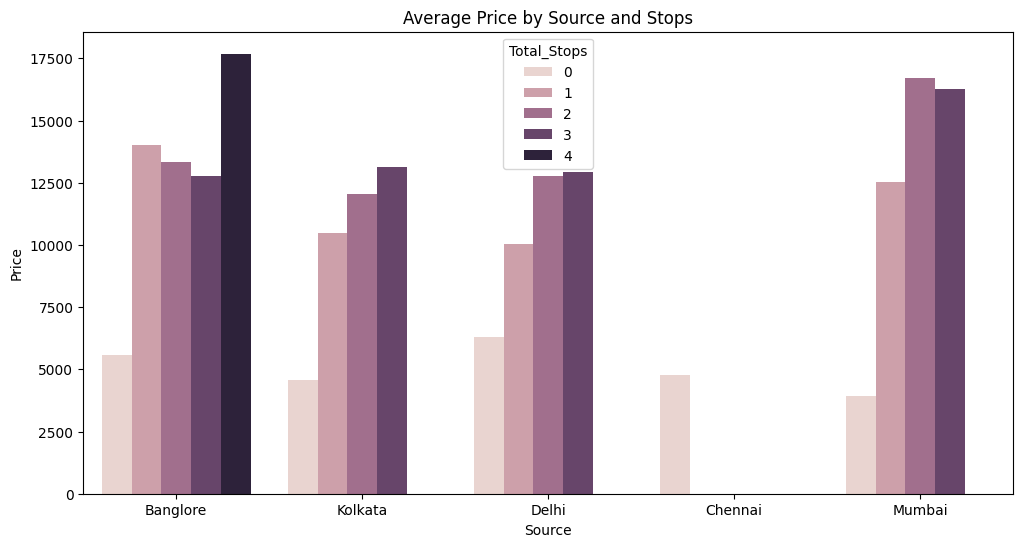

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='Source',y='Price',hue='Total_Stops',data=df,ci= None) # with the help of CI we remove the line of outlier from bar
plt.title('Average Price by Source and Stops')
plt.show()


**Multi-stop flights are cheaper across cities**

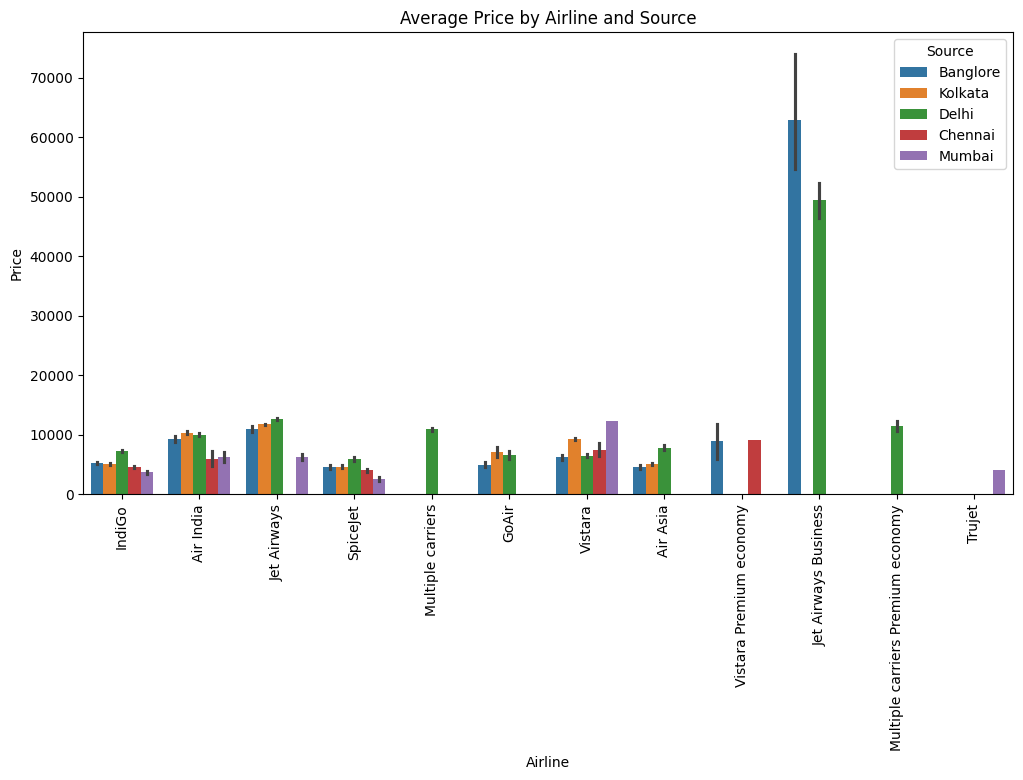

In [ ]:
plt.figure(figsize=(12,6))
sns.barplot(x='Airline',y='Price',hue='Source',data=df)
plt.xticks(rotation=90)
plt.title('Average Price by Airline and Source')
plt.show()


**the highest ticket sold (pricewise) jet airways business and the the source is banglore and delhi**

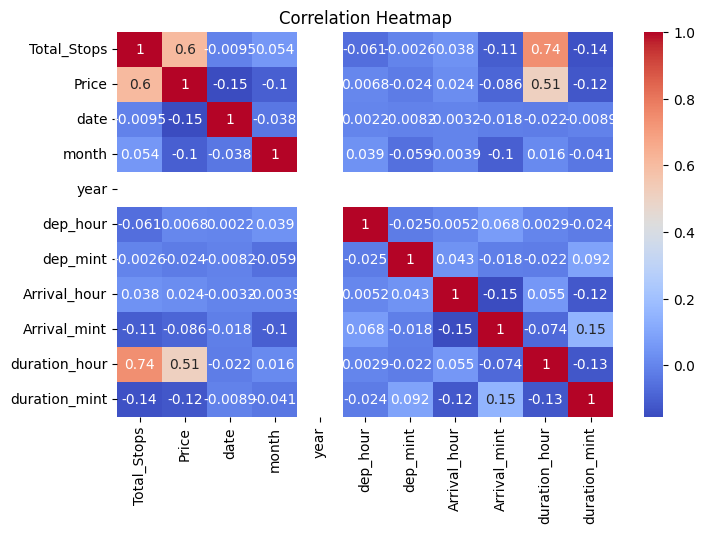

In [ ]:
num_cols = nums

plt.figure(figsize=(8,5))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()


In [ ]:
df = pd.get_dummies(df,columns=["Airline", "Source", "Destination"],drop_first=True) #one hot encoding convertin cat data into nums for ML because ML only undestand numbers


In [ ]:
df # checking the and confirming that is our data converted or not.

,Total_Stops,Price,date,month,year,dep_hour,dep_mint,Arrival_hour,Arrival_mint,duration_hour,...,Airline_Vistara Premium economy,Source_Chennai,Source_Delhi,Source_Kolkata,Source_Mumbai,Destination_Cochin,Destination_Delhi,Destination_Hyderabad,Destination_Kolkata,Destination_New Delhi
0,0,3897,24,3,2019,22,20,1,10,2,...,False,False,False,False,False,False,False,False,False,True
1,2,7662,1,5,2019,5,50,13,15,7,...,False,False,False,True,False,False,False,False,False,False
2,2,13882,9,6,2019,9,25,4,25,19,...,False,False,True,False,False,True,False,False,False,False
3,1,6218,12,5,2019,18,5,23,30,5,...,False,False,False,True,False,False,False,False,False,False
4,1,13302,1,3,2019,16,50,21,35,4,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10678,0,4107,9,4,2019,19,55,22,25,2,...,False,False,False,True,False,False,False,False,False,False
10679,0,4145,27,4,2019,20,45,23,20,2,...,False,False,False,True,False,False,False,False,False,False
10680,0,7229,27,4,2019,8,20,11,20,3,...,False,False,False,False,False,False,True,False,False,False
10681,0,12648,1,3,2019,11,30,14,10,2,...,False,False,False,False,False,False,False,False,False,True


In [ ]:
from sklearn.linear_model import LinearRegression   # importing library for ML
from sklearn.metrics import r2_score,mean_absolute_error,mean_squared_error,accuracy_score
from sklearn.model_selection import train_test_split

In [ ]:
x = df.drop(columns=["Price"])  # Priceis are target variable so now we separting data into x and y
y = df["Price"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
model = LinearRegression()  # fitting linearregression into model
model.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred = model.predict(X_test)

In [343]:
r2_score(y_test,y_pred) # checking our model R2 score

0.6195911867006523

In [ ]:
mea = mean_absolute_error(y_test,y_pred)  # checking are mea,mse,rmse and r2
mse = mean_squared_error(y_test,y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test,y_pred)
print(f"Mean Absolute Error: {mea}")
print(f"Mean Squared Error: {mse}")
print(f"Root Mean Squared Error: {rmse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 1972.9241585981356
Mean Squared Error: 8202396.258568081
Root Mean Squared Error: 2863.9825869875817
R-squared: 0.6195911867006523


#conclusion

**This project demonstrates a complete data analytics workflow — from raw data cleaning to multivariate analysis and machine learning preparation — uncovering key factors that influence flight ticket pricing and enabling accurate predictive modeling.**